# Tutorial: Multi-Agent PDE Control for 2D Heat Tracking

Welcome to the next phase of our interactive tutorial! Previously, we focused on suppressing 1D chaos using static actuators. Now, we are stepping up the complexity. 

In this section, we will control a **2D thermal diffusion process**. Instead of simply stabilizing the system to zero, our objective is **reference tracking**: we want to drive an initial temperature field to match a specific, complex 2D target configuration. To achieve this, our neural operator policy will control a swarm of **mobile actuators**, dictating both how much heat they inject/extract and where they should move.

## 1. Problem Formulation

We consider the optimal control of a 2D state field, $z(x,y,t)$, evolving over a spatial domain $\Omega \subset \mathbb{R}^2$ (specifically, a grid) and a finite time horizon $t \in [0,T]$. 

The system is actuated by a swarm of $M$ mobile agents. For each agent $i \in \{1, \dots, M\}$:
* $\xi_i(t) \in \Omega$ is the agent's 2D spatial position $(x_i, y_i)$.
* $u_i(t) \in \mathbb{R}$ is the localized control intensity (heating or cooling).
* $v_i(t) \in \mathbb{R}^2$ is the agent's 2D velocity vector, such that $\dot{\xi}_i(t) = v_i(t)$.

## 2. The 2D Heat Equation

The intrinsic dynamics of our system are governed by the 2D Heat Equation, a linear parabolic PDE that models the diffusion of thermal energy over time:

$$\frac{\partial z}{\partial t} = \nu \nabla^2 z + \sum_{i=1}^M \mathcal{B}(x, y, u_i(t), \xi_i(t))$$

Where:
* $\nabla^2 z = \left( \frac{\partial^2 z}{\partial x^2} + \frac{\partial^2 z}{\partial y^2} \right)$ is the spatial Laplacian, driving natural dissipation and smoothing.
* $\nu$ is the diffusion coefficient, controlling how fast the heat naturally spreads.

## 3. The 2D Actuation Model

Just like in the 1D case, we map the discrete agents onto the continuous PDE field using a Gaussian kernel, but expanded to two dimensions. The total forcing applied to the environment is:

$$\mathcal{B}(x, y, u(t)) = \sum_{i=1}^M b(x, y, \xi_i(t)) u_i(t)$$

The spatial footprint of an individual agent is a 2D Gaussian bell curve:

$$b(x, y, \xi) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{||(x,y) - \xi||^2}{2\sigma^2}\right)$$

Where $\sigma$ is the physical width of the actuator's influence zone.

## 4. The Learning Objective

Because our actuators are now mobile, the neural operator must learn to balance three competing objectives:
1.  **Tracking Error:** How closely the current field $z(x,y,t)$ matches the target field $z_{target}(x,y)$.
2.  **Intensity Effort:** The energy expended to heat or cool the environment.
3.  **Kinematic Effort:** The energy expended by the agents to move around the domain.

We train the shared policy by backpropagating through the differentiable 2D physics solver to minimize this composite loss function:

$$\mathcal{L}_{total} = \lambda_{track} \int_\Omega (z - z_{target})^2 d\Omega + \frac{1}{M} \sum_{i=1}^M \left( \lambda_{effort} u_i(t)^2 + \lambda_{kinematic} ||v_i(t)||^2 \right)$$

This forces the swarm to dynamically route themselves to areas of high error, inject the necessary energy, and then hold their positions efficiently as the system reaches the desired state.

## 5. Building the 2D Differentiable Physics Solver

Moving from 1D to 2D significantly increases the computational load. For the 2D Heat Equation, we will model the environment on a $N \times N$ spatial grid. 

To keep this tutorial accessible and fast, we will implement an explicit Finite Difference (FD) solver using JAX's 2D convolutions to compute the spatial Laplacian ($\nabla^2 z$). We will also strictly enforce **Dirichlet boundary conditions** ($z = 0$ at the edges of the domain).

Let's write the 2D forcing function for our mobile agents and the discrete physics step.

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit
from functools import partial

%pip install cmcrameri

# Configuration 
N = 32  # Grid size is 32x32
dx = 1.0 / N
dy = 1.0 / N
x_grid = jnp.linspace(0, 1, N)
y_grid = jnp.linspace(0, 1, N)
xx, yy = jnp.meshgrid(x_grid, y_grid, indexing='ij')

nu = 0.2      # Diffusion coefficient
sigma = 0.15  # Width of the actuator influence
fixed_dt = 0.001

def build_implicit_matrix_1d(N, r):
    """
    Builds the LHS matrix for Crank-Nicolson: (I + r/2 * L)
    where L is the Laplacian operator in 1D.
    """
    main_diag = jnp.ones(N) * (1 + r)
    off_diag = jnp.ones(N - 1) * (-r / 2.0)

    A = jnp.diag(main_diag) + jnp.diag(off_diag, k=1) + jnp.diag(off_diag, k=-1)

    # Dirichlet Boundary Conditions (zero at ends)
    A = A.at[0, :].set(0.0).at[0, 0].set(1.0)
    A = A.at[-1, :].set(0.0).at[-1, -1].set(1.0)
    return A

def forcing_fn(xx, yy, xi, u):
    """
    2D Gaussian actuator forcing mapping discrete agents to the continuous grid.
    """
    # Compute squared distance
    dx_sq = (xx[None, :, :] - xi[:, 0, None, None])**2
    dy_sq = (yy[None, :, :] - xi[:, 1, None, None])**2
    sq_dist = dx_sq + dy_sq

    # Gaussian basis
    basis = jnp.exp(-sq_dist / (2 * sigma**2))

    # Sum contributions
    B = jnp.sum(u[:, None, None] * basis, axis=0)
    return B

@jit
def adi_step(z, xi, u, v):
    """
    ADI Crank-Nicolson step for 2D heat equation.
    """
    dt = fixed_dt
    r = nu * dt / (dx**2)

    # Precompute forcing
    B = forcing_fn(xx, yy, xi, u)

    # Build 1D tridiagonal matrix 
    A = build_implicit_matrix_1d(N, r)

    # --- STEP 1: Implicit in X, Explicit in Y ---
    def solve_x_row(j):
        def boundary_case():
            return jnp.zeros(N)

        def interior_case():
            z_row = z[:, j]  
            z_left = z[:, j-1]
            z_right = z[:, j+1]

            # Explicit part: (I + r/2 * L_y) z + dt/2 * B
            diff_y = (r / 2.0) * (z_left - 2*z_row + z_right)
            rhs = z_row + diff_y + (dt / 2.0) * B[:, j]

            # Enforce boundary conditions in RHS
            rhs = rhs.at[0].set(0.0)
            rhs = rhs.at[-1].set(0.0)

            return jnp.linalg.solve(A, rhs)

        return jax.lax.cond((j == 0) | (j == N-1), boundary_case, interior_case)

    z_star_rows = jax.vmap(solve_x_row)(jnp.arange(N))
    z_star = z_star_rows.T  

    # --- STEP 2: Implicit in Y, Explicit in X ---
    def solve_y_col(i):
        def boundary_case():
            return jnp.zeros(N)

        def interior_case():
            z_col = z_star[i, :]  
            z_down = z_star[i-1, :]
            z_up = z_star[i+1, :]

            # Explicit part in x
            diff_x = (r / 2.0) * (z_down - 2*z_col + z_up)
            rhs = z_col + diff_x + (dt / 2.0) * B[i, :]

            rhs = rhs.at[0].set(0.0)
            rhs = rhs.at[-1].set(0.0)

            return jnp.linalg.solve(A, rhs)

        return jax.lax.cond((i == 0) | (i == N-1), boundary_case, interior_case)

    z_next = jax.vmap(solve_y_col)(jnp.arange(N)) 

    # Update actuator kinematic positions
    xi_next = xi + dt * v
    xi_next = jnp.clip(xi_next, 0.0, 1.0)

    return z_next, xi_next

@partial(jax.jit, static_argnums=(4, 5))
def solve_with_policy(z_init, xi_init, z_target, params, policy_apply_fn, t_steps):
    """
    Main JAX scanner to unroll the differentiable physics step over time.
    """
    def step_fn(carry, _):
        z_curr, xi_curr = carry
        
        # Query the neural operator policy
        u, v = policy_apply_fn(params, z_curr, z_target, xi_curr)
        
        # Evolve the physics
        z_next, xi_next = adi_step(z_curr, xi_curr, u, v)
        
        return (z_next, xi_next), (z_next, xi_next, u, v)

    _, trajectory = jax.lax.scan(
        step_fn,
        (z_init, xi_init),
        None,
        length=t_steps
    )

    return trajectory

Note: you may need to restart the kernel to use updated packages.


W0604 08:58:23.968959   15184 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0604 08:58:23.970301   13133 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


## 6. Generating Rigorous 2D Initial and Target Conditions

For the 2D Heat tracking task, we need to generate smooth Gaussian Random Fields (GRFs) that strictly obey Dirichlet boundary conditions ($z=0$ at the edges).

Instead of approximating this with a masking function, we compute the exact GRF using the eigendecomposition of an RBF kernel, and then apply a **2D Bridge Correction**. This interpolates the boundary values and subtracts them from the field, anchoring the edges to zero while preserving the complex, smooth topological features in the center of the domain.


Found existing dataset at 'heat2d_dataset_32x32_tutorial.npz'. Loading data...
Successfully loaded 1000 (Initial, Target) pairs!


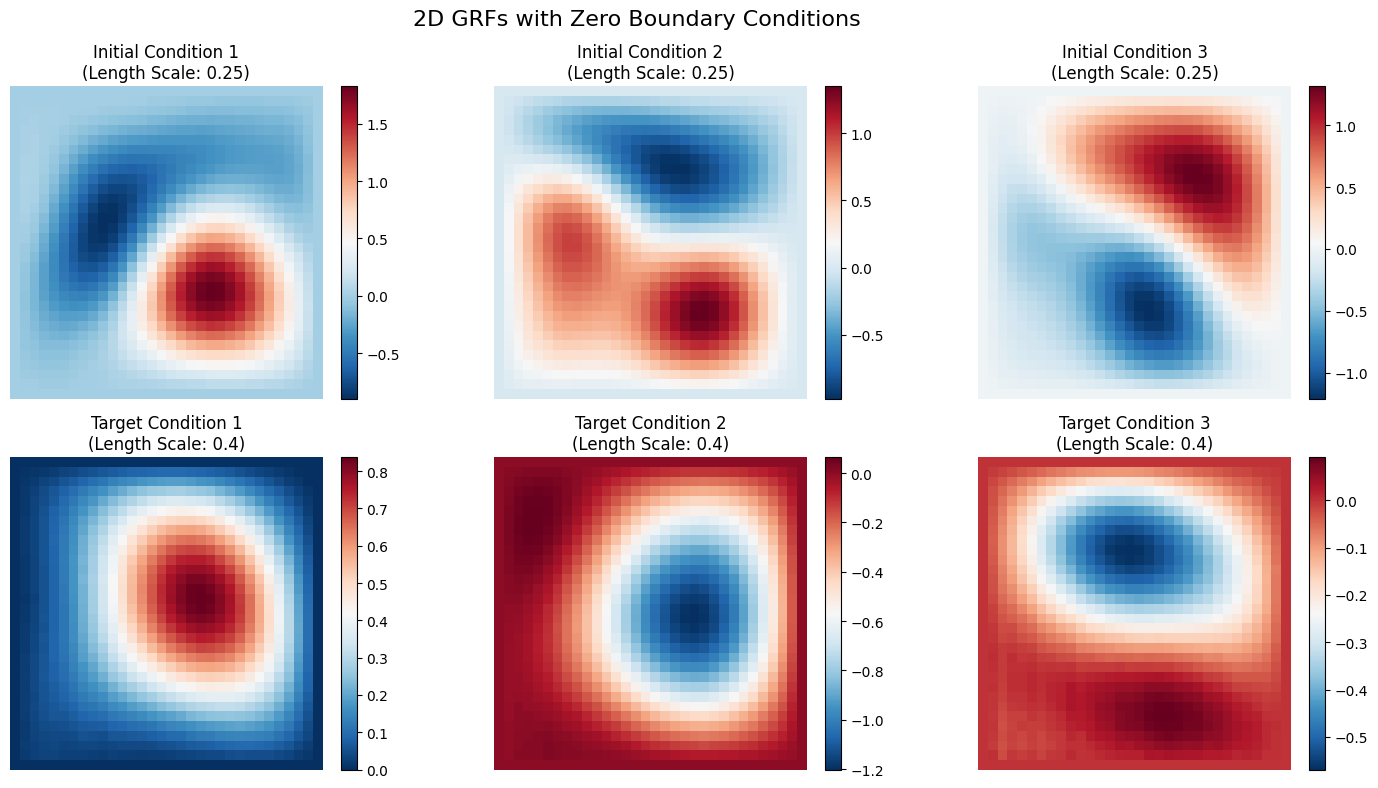

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

N_GRID = 32
N_SAMPLES = 1000
LENGTH_SCALE_INIT = 0.25
LENGTH_SCALE_TARGET = 0.4
SIGMA = 1.0

def rbf_kernel_2d(x1, x2, length_scale=0.3, sigma=1.0):
    """2D RBF kernel for GRF generation."""
    diff = x1[:, None, :] - x2[None, :, :]
    dist_sq = jnp.sum(diff**2, axis=-1)  
    return sigma**2 * jnp.exp(-0.5 * dist_sq / length_scale**2)

def generate_grf_2d(key, n_points=32, length_scale=0.4, sigma=1.0):
    """Generate 2D Gaussian Random Field with zero Dirichlet BCs."""
    with jax.default_device(jax.devices("cpu")[0]):  # CPU for eigen-decomp
        # Create Grid
        x_grid = jnp.linspace(0, 1, n_points)
        y_grid = jnp.linspace(0, 1, n_points)
        xx, yy = jnp.meshgrid(x_grid, y_grid, indexing='ij')

        # Flatten grid to (N², 2)
        grid_flat = jnp.stack([xx.ravel(), yy.ravel()], axis=-1)

        # Covariance matrix (N², N²) 
        K = rbf_kernel_2d(grid_flat, grid_flat, length_scale, sigma)

        # Eigendecomposition
        w, V = jnp.linalg.eigh(K)
        w_sqrt = jnp.sqrt(jnp.maximum(w, 1e-12))

        # Sample
        z = jax.random.normal(key, shape=(n_points**2,))
        f_flat = V @ (w_sqrt * z)

    # Reshape to 2D
    f = f_flat.reshape((n_points, n_points))

    # --- 2D Bridge Correction (Enforcing z=0 on edges) ---
    f_left, f_right = f[0, :], f[-1, :]    
    f_bottom, f_top = f[:, 0], f[:, -1]      
    f_00, f_10, f_01, f_11 = f[0, 0], f[-1, 0], f[0, -1], f[-1, -1]

    x_norm, y_norm = xx, yy

    # Trend surface via bilinear interpolation
    corner_trend = ((1 - x_norm) * (1 - y_norm) * f_00 +
                    x_norm * (1 - y_norm) * f_10 +
                    (1 - x_norm) * y_norm * f_01 +
                    x_norm * y_norm * f_11)

    left_edge_interp = (1 - y_norm) * f_00 + y_norm * f_01
    left_contrib = (1 - x_norm) * (f_left[None, :] - left_edge_interp)

    right_edge_interp = (1 - y_norm) * f_10 + y_norm * f_11
    right_contrib = x_norm * (f_right[None, :] - right_edge_interp)

    bottom_edge_interp = (1 - x_norm) * f_00 + x_norm * f_10
    bottom_contrib = (1 - y_norm) * (f_bottom[:, None] - bottom_edge_interp)

    top_edge_interp = (1 - x_norm) * f_01 + x_norm * f_11
    top_contrib = y_norm * (f_top[:, None] - top_edge_interp)

    trend = corner_trend + left_contrib + right_contrib + bottom_contrib + top_contrib
    
    # Subtract trend to force edges to zero
    field = f - trend
    return xx, yy, field

# --- Smart Data Loading / Generation ---
filename = f'heat2d_dataset_{N_GRID}x{N_GRID}_tutorial.npz'

if os.path.exists(filename):
    print(f"Found existing dataset at '{filename}'. Loading data...")
    data = np.load(filename, allow_pickle=True)
    z_init_all = jnp.array(data['z_init'])
    z_target_all = jnp.array(data['z_target'])
    
    # Handle case where requested samples differ from saved samples
    loaded_samples = len(z_init_all)
    if loaded_samples > N_SAMPLES:
        print(f"Slicing first {N_SAMPLES} samples from the dataset.")
        z_init_all = z_init_all[:N_SAMPLES]
        z_target_all = z_target_all[:N_SAMPLES]
    elif loaded_samples < N_SAMPLES:
        print(f"Warning: Loaded dataset only has {loaded_samples} samples, but {N_SAMPLES} were requested.")
        
    print(f"Successfully loaded {len(z_init_all)} (Initial, Target) pairs!")

else:
    print(f"Dataset not found at '{filename}'. Generating {N_SAMPLES} initial and target pairs...")
    key = jax.random.PRNGKey(42)
    all_keys = jax.random.split(key, N_SAMPLES * 2)

    z_init_list = []
    z_target_list = []

    for i in range(N_SAMPLES):
        # Initial Conditions (More textured, lower length scale)
        _, _, z_i = generate_grf_2d(all_keys[i], n_points=N_GRID, length_scale=LENGTH_SCALE_INIT, sigma=SIGMA)
        z_init_list.append(z_i)
        
        # Target Conditions (Smoother, higher length scale)
        _, _, z_t = generate_grf_2d(all_keys[N_SAMPLES + i], n_points=N_GRID, length_scale=LENGTH_SCALE_TARGET, sigma=SIGMA)
        z_target_list.append(z_t)

    z_init_all = jnp.array(z_init_list)
    z_target_all = jnp.array(z_target_list)

    # --- Save to .npz ---
    np.savez_compressed(
        filename,
        z_init=z_init_all,
        z_target=z_target_all,
        grid_size=N_GRID,
        n_samples=N_SAMPLES
    )
    print(f"Dataset successfully generated and saved to {filename}")

# --- Visualize Results ---
n_plot = min(3, len(z_init_all))

if n_plot > 0:
    fig, axes = plt.subplots(2, n_plot, figsize=(5 * n_plot, 8))
    # Handle the case where n_plot is 1 (axes is 1D)
    if n_plot == 1:
        axes = np.expand_dims(axes, axis=1)
        
    fig.suptitle("2D GRFs with Zero Boundary Conditions", fontsize=16)

    for i in range(n_plot):
        # Plot Initial Conditions
        im_init = axes[0, i].imshow(z_init_all[i], origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r')
        axes[0, i].set_title(f'Initial Condition {i+1}\n(Length Scale: {LENGTH_SCALE_INIT})')
        axes[0, i].axis('off')
        plt.colorbar(im_init, ax=axes[0, i], fraction=0.046, pad=0.04)
        
        # Plot Target Conditions
        im_target = axes[1, i].imshow(z_target_all[i], origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r')
        axes[1, i].set_title(f'Target Condition {i+1}\n(Length Scale: {LENGTH_SCALE_TARGET})')
        axes[1, i].axis('off')
        plt.colorbar(im_target, ax=axes[1, i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

## 7. The Decentralized DeepONet Policy

Now that we have our differentiable 2D physics solver and our training data, we need the "brain" of our swarm. We will use a **Decentralized DeepONet** architecture built with Flax.

In this decentralized setup, all $M$ agents share the exact same neural network weights, but they act independently based on their unique local perspectives. The network consists of three main parts:
1. **The Branch Net:** An agent doesn't see the whole board. It extracts a local $12 \times 12$ spatial patch around its current position, observing the tracking error and the error gradients. A Convolutional Neural Network (CNN) processes this patch.
2. **The Trunk Net:** To ensure the agent knows *where* it is in the global domain, we encode its absolute $(x, y)$ coordinates using Fourier features.
3. **Fusion & Output:** The network combines the visual features (Branch) and spatial features (Trunk) to output two things: the heating/cooling intensity ($u$) and the 2D movement velocity ($v$).

In [ ]:
import flax.linen as nn
from typing import Sequence

class Heat2DControlNet(nn.Module):
    """
    2D Heat Controller.
    Each agent perceives a local patch around its position.
    """
    features: Sequence[int] = (16, 32)
    u_max: float = 40.0
    v_max: float = 5.0  # Max velocity (increased for better coverage)
    patch_size: int = 12  # Local window size (12×12 patch)

    def setup(self):
        self.frequencies = jnp.array([1.0, 2.0, 4.0, 8.0])

    def extract_local_patch(self, field, xi, n_grid):
        """Extract local patch around actuator position."""
        # Convert position to grid index
        i = jnp.clip((xi[0] * (n_grid - 1)).astype(int), 0, n_grid-1)
        j = jnp.clip((xi[1] * (n_grid - 1)).astype(int), 0, n_grid-1)

        half_patch = self.patch_size // 2

        # Pad field to handle boundaries
        padded_field = jnp.pad(field, ((half_patch, half_patch),
                                        (half_patch, half_patch)),
                                mode='edge')

        start_i = i
        start_j = j

        patch = jax.lax.dynamic_slice(
            padded_field,
            (start_i, start_j),
            (self.patch_size, self.patch_size)
        )
        return patch

    def branch_net(self, local_patch):
        """Process local 3-channel patch."""
        x = local_patch  # (patch_size, patch_size, 3)

        for feat in self.features:
            x = nn.Conv(feat, kernel_size=(3, 3), padding='SAME')(x)
            x = nn.relu(x)

        x = x.reshape(-1)
        x = x / (jnp.linalg.norm(x) + 1.0)  # Local normalization
        x = nn.Dense(32)(x)
        x = nn.tanh(x)
        return x

    def trunk_net(self, xi):
        """Encode absolute coordinates."""
        angle_x = xi[:, 0, None] * self.frequencies * jnp.pi
        angle_y = xi[:, 1, None] * self.frequencies * jnp.pi

        encoded = jnp.concatenate([
            jnp.sin(angle_x), jnp.cos(angle_x),
            jnp.sin(angle_y), jnp.cos(angle_y)
        ], axis=-1)

        for feat in [32, 32]:
            encoded = nn.Dense(feat)(encoded)
            encoded = nn.tanh(encoded)
        return encoded

    @nn.compact
    def __call__(self, z_curr, z_target, xi_curr):
        error = z_curr - z_target
        error_grad = jnp.gradient(error)
        error_grad_x = error_grad[1]  # Swap to x, y
        error_grad_y = error_grad[0]

        n_grid = z_curr.shape[0]

        # Extract local patches for each agent
        def get_local_obs(xi_single):
            patch_error = self.extract_local_patch(error, xi_single, n_grid)
            patch_grad_x = self.extract_local_patch(error_grad_x, xi_single, n_grid)
            patch_grad_y = self.extract_local_patch(error_grad_y, xi_single, n_grid)
            return jnp.stack([patch_error, patch_grad_x, patch_grad_y], axis=-1)

        local_patches = jax.vmap(get_local_obs)(xi_curr)  # (M, patch, patch, 3)

        # Process each patch independently
        branch_outs = jax.vmap(self.branch_net)(local_patches)

        # Trunk encoding
        trunk_outs = self.trunk_net(xi_curr)

        # Fusion and output
        combined = jnp.concatenate([branch_outs, trunk_outs], axis=-1)
        h = nn.Dense(64)(combined)
        h = nn.tanh(h)

        u_raw = nn.Dense(1)(h).squeeze(-1)
        v_raw = nn.Dense(2)(h)

        return self.u_max * jnp.tanh(u_raw), self.v_max * jnp.tanh(v_raw)

## 8. Differentiable Physics Training

With our environment and policy defined, we can construct the training loop. We will train the network using **Backpropagation Through Time (BPTT)**. Because our 2D Heat solver is written entirely in JAX, we can unroll the simulation for $T$ steps and seamlessly compute the gradients of our loss function with respect to the neural network parameters.

We penalize five distinct behaviors to shape the swarm's strategy:
1. **Tracking Loss:** The Mean Squared Error between the current heat field and the target.
2. **Effort Loss:** Energy spent heating/cooling and moving.
3. **Boundary Penalty:** Prevents agents from flying off the grid.
4. **Collision Avoidance:** A repulsive penalty to keep agents a safe distance from one another.
5. **Acceleration Penalty:** Encourages smooth, realistic motion.

In [ ]:
import optax
import time
from tqdm.auto import trange

# --- Setup Dynamics Wrapper ---
class PDEDynamics:
    def __init__(self, policy_apply_fn):
        self.policy_apply_fn = policy_apply_fn

    def unroll_controlled(self, z_init, xi_init, z_target, params, t_steps):
        # Calls the solve_with_policy function we defined earlier
        return solve_with_policy(z_init, xi_init, z_target, params, self.policy_apply_fn, t_steps)

# --- Training Configuration ---
N_AGENTS = 16 
R_SAFE = 0.08
BATCH_SIZE = 16
T_STEPS = 300     
EPOCHS = 500

print(f"Initializing Decentralized ControlNet with {N_AGENTS} agents...")
model = Heat2DControlNet(features=(16, 32))
key = jax.random.PRNGKey(0)

# Init network weights
dummy_z = jnp.zeros((N_GRID, N_GRID))
dummy_xi = jnp.zeros((N_AGENTS, 2))
params = model.init(key, dummy_z, dummy_z, dummy_xi)

# Setup Optimizer
lr_schedule = optax.exponential_decay(1e-3, 2000, 0.5)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr_schedule))
opt_state = optimizer.init(params)
dynamics = PDEDynamics(policy_apply_fn=model.apply)

# --- Loss Function ---
def loss_fn(params, z_init, xi_init, z_target, dynamics):
    z_traj, xi_traj, u_traj, v_traj = dynamics.unroll_controlled(
        z_init, xi_init, z_target, params, T_STEPS
    )

    # 1. Tracking loss
    l_track = jnp.mean((z_traj - z_target[None, :, :]) ** 2)

    # 2. Effort loss
    l_effort = jnp.mean(u_traj ** 2) + 0.1 * jnp.mean(jnp.sum(v_traj ** 2, axis=-1))

    # 3. Boundary penalty (Keep agents inside domain)
    margin = 0.02
    x_penalty = jnp.maximum(0, margin - xi_traj[:, :, 0])**2 + \
                jnp.maximum(0, xi_traj[:, :, 0] - (1.0 - margin))**2
    y_penalty = jnp.maximum(0, margin - xi_traj[:, :, 1])**2 + \
                jnp.maximum(0, xi_traj[:, :, 1] - (1.0 - margin))**2
    l_bound = jnp.mean(x_penalty + y_penalty)

    # 4. Collision avoidance
    diff = xi_traj[:, :, None, :] - xi_traj[:, None, :, :]
    dists = jnp.sqrt(jnp.sum(diff**2, axis=-1) + 1e-8)
    mask = jnp.eye(N_AGENTS)[None, :, :]
    l_coll = jnp.mean(jnp.maximum(0, R_SAFE - (dists + mask * 10.0)) ** 2)

    # 5. Acceleration penalty
    l_accel = jnp.mean(jnp.sum(jnp.diff(v_traj, axis=0)**2, axis=-1))

    # Weighted Sum
    total_loss = (5.0 * l_track) + (0.001 * l_effort) + (100.0 * l_bound) + \
                 (20.0 * l_coll) + (0.1 * l_accel)

    return total_loss, (l_track, l_effort, l_coll, l_bound)

@partial(jax.jit, static_argnames='dynamics')
def train_step(params, opt_state, z_init_batch, xi_init_batch, z_target_batch, dynamics):
    batched_loss_fn = jax.vmap(loss_fn, in_axes=(None, 0, 0, 0, None))

    def mean_loss_fn(p):
        losses, auxs = batched_loss_fn(p, z_init_batch, xi_init_batch, z_target_batch, dynamics)
        return jnp.mean(losses), jax.tree_util.tree_map(jnp.mean, auxs)

    (loss, aux), grads = jax.value_and_grad(mean_loss_fn, has_aux=True)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, aux

# --- Prepare Agent Initial Positions ---
# Distribute agents in a uniform 4x4 grid
n_side = int(jnp.sqrt(N_AGENTS))
positions_1d = jnp.array([0.2, 0.4, 0.6, 0.8])[:n_side]
xi_template = [[float(x), float(y)] for x in positions_1d for y in positions_1d]
xi_init_batch = jnp.tile(jnp.array(xi_template), (BATCH_SIZE, 1, 1))

# --- Execute Training ---
metrics = []
start_time = time.time()
print("\nCommencing DPC Training Loop...")

for epoch in trange(EPOCHS):
    key, subkey = jax.random.split(key)
    
    # Grab a random batch using the correct variable names: z_init_all and z_target_all
    idx = jax.random.randint(subkey, (BATCH_SIZE,), 0, len(z_init_all))
    z_init_b, z_target_b = z_init_all[idx], z_target_all[idx]

    # Perform gradient step
    params, opt_state, loss, aux = train_step(
        params, opt_state, z_init_b, xi_init_batch, z_target_b, dynamics
    )

    if epoch % 10 == 0:
        metrics.append((epoch, loss, *aux))
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Track: {aux[0]:.4f} | " +
              f"Effort: {aux[1]:.4f} | Coll: {aux[2]:.4f} | Bound: {aux[3]:.4f}")

print(f"\nTraining finished in {time.time() - start_time:.2f}s.")

Initializing Decentralized ControlNet with 16 agents...

Commencing DPC Training Loop...


  0%|          | 1/500 [00:03<31:27,  3.78s/it]

Epoch 000 | Loss: 3.8074 | Track: 0.7500 | Effort: 54.3369 | Coll: 0.0001 | Bound: 0.0000


  2%|▏         | 11/500 [00:05<02:02,  3.99it/s]

Epoch 010 | Loss: 0.1773 | Track: 0.0278 | Effort: 32.2627 | Coll: 0.0002 | Bound: 0.0000


...

Epoch 480 | Loss: 0.0705 | Track: 0.0094 | Effort: 22.6553 | Coll: 0.0000 | Bound: 0.0000


 98%|█████████▊| 491/500 [02:01<00:02,  4.47it/s]

Epoch 490 | Loss: 0.0706 | Track: 0.0092 | Effort: 23.7260 | Coll: 0.0000 | Bound: 0.0000


100%|██████████| 500/500 [02:03<00:00,  4.05it/s]


Training finished in 123.48s.


## 9. Cardinality Invariance: Scaling the Swarm Zero-Shot

A central feature of our Neural Operator framework is **cardinality invariance**: the ability to train a policy on a specific number of agents ($M_{train}$) and deploy it to a completely different swarm size ($M_{test} \neq M_{train}$) without any fine-tuning or retraining. 

Traditional Multi-Agent Reinforcement Learning (MARL) methods often fix the state-action dimensions to a specific swarm size, requiring complete retraining if the actuator configuration changes. In our decentralized approach, however, agents share a common policy and coordinate implicitly through their shared physical environment (the PDE field). 

This zero-shot scalability is driven by a phenomenon called **emergent self-normalization**. Because our loss function explicitly penalizes control effort during training, the shared policy learns to balance individual agent contributions against the magnitude of the global field. When deployed with a larger swarm, the feedback loop through the physics automatically adjusts the aggregate forcing. The agents learn to scale down their individual forcing intensities (approximately $O(1/M)$), ensuring that the total force applied to the system remains optimal and bounded.

Let's see this in action! We trained our model using $M = 16$ agents. In the following cells, we will evaluate this *exact same trained policy* on $M = 16$, $M = 25$, $M = 36$ and $M = 64$ agents to observe cardinality invariance at work.

In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib import colors as mcolors
import matplotlib.patheffects as pe
import cmcrameri.cm as cmc
import flax.serialization

VIZ_T_STEPS = 300
SNAPSHOT_TIMES = [0, 30, 80, 150, 299]
PARAMS_FILE = 'decentralized_params_heat2d.msgpack'

def setup_paper_style():
    """Configure matplotlib for publication-quality figures."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.5,
        "axes.spines.top": True,
        "axes.spines.right": True,
    })

def load_params_for_agents(model, filepath, n_agents):
    """Loads the trained weights and maps them to any number of agents."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Parameter file {filepath} not found. Run training cell first.")
    
    with open(filepath, 'rb') as f:
        serialized_bytes = f.read()
    
    key = jax.random.PRNGKey(0)
    dummy_z = jnp.zeros((N_GRID, N_GRID))
    dummy_xi = jnp.zeros((n_agents, 2))
    init_params = model.init(key, dummy_z, dummy_z, dummy_xi)
    return flax.serialization.from_bytes(init_params, serialized_bytes)

@partial(jax.jit, static_argnums=(2,))
def rollout_uncontrolled(z_init, xi_init, t_steps):
    """Rollout the environment with zero control inputs using the internal adi_step."""
    def step_fn(carry, _):
        z_curr, xi_curr = carry
        u_zero = jnp.zeros(xi_curr.shape[0])
        v_zero = jnp.zeros_like(xi_curr)
        z_next, xi_next = adi_step(z_curr, xi_curr, u_zero, v_zero)
        return (z_next, xi_next), (z_next, xi_next, u_zero, v_zero)

    _, (z_traj, xi_traj, u_traj, v_traj) = jax.lax.scan(
        step_fn, (z_init, xi_init), None, length=t_steps
    )
    return z_traj, xi_traj, u_traj, v_traj

# --- Generate the SHARED evaluation shape ---
print("Generating shared evaluation shape for all agents...")
eval_key = jax.random.PRNGKey(4242)
_, k1, k2 = jax.random.split(eval_key, 3)

# Using internal generate_grf_2d from Cell 6
_, _, shared_z_init = generate_grf_2d(k1, n_points=N_GRID, length_scale=LENGTH_SCALE_INIT, sigma=SIGMA)
_, _, shared_z_target = generate_grf_2d(k2, n_points=N_GRID, length_scale=LENGTH_SCALE_TARGET, sigma=SIGMA)

def get_agent_positions(n_agents):
    """Distribute N agents evenly across the domain."""
    n_side = int(jnp.sqrt(n_agents))
    positions_1d = jnp.linspace(0.1, 0.9, n_side) 
    xi_init = [[float(x), float(y)] for x in positions_1d for y in positions_1d]
    return jnp.array(xi_init)

# --- Plotting Functions ---
def plot_snapshot_row(ax_list, z_traj, xi_traj, timesteps, v_lim, show_agents=False, z_ref=None):
    """Plot a row of temperature field snapshots using contourf."""
    x = np.linspace(0, 1, N_GRID)
    y = np.linspace(0, 1, N_GRID)
    X, Y = np.meshgrid(x, y)
    levels = np.linspace(-v_lim, v_lim, 100)
    ref_levels = np.linspace(-v_lim, v_lim, 11)
    zero_gap = 0.02 * v_lim
    ref_levels = ref_levels[np.abs(ref_levels) >= zero_gap]
    
    norm = mcolors.Normalize(vmin=-v_lim, vmax=v_lim)
    cf = None
    
    for i, t in enumerate(timesteps):
        ax = ax_list[i]
        z_snap = np.array(z_traj[t])
        
        cf = ax.contourf(X, Y, z_snap, levels=levels, cmap=cmc.vik, extend='both')

        if z_ref is not None:
            cs = ax.contour(X, Y, np.array(z_ref), levels=ref_levels, cmap=cmc.vik, 
                            norm=norm, linestyles='--', linewidths=0.8, alpha=1.0, zorder=6)
            shadow_effect = pe.Stroke(linewidth=1.1, foreground='black', alpha=0.15)
            cs.set_path_effects([shadow_effect, pe.Normal()])
        
        if show_agents and xi_traj is not None:
            xi = xi_traj[t]
            ax.scatter(xi[:, 1], xi[:, 0], c='#E74C3C', s=16, edgecolors='white', 
                       linewidths=0.8, zorder=10)
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)
            
        ax.set_xlabel(f"t={t}", fontsize=11)
    
    return cf

def plot_error_row(ax_list, z_traj, z_target, timesteps, e_lim):
    """Plot a row displaying the absolute tracking error."""
    x = np.linspace(0, 1, N_GRID)
    y = np.linspace(0, 1, N_GRID)
    X, Y = np.meshgrid(x, y)
    levels = np.linspace(0, e_lim, 100)
    
    cf = None
    z_target_np = np.array(z_target)
    
    for i, t in enumerate(timesteps):
        ax = ax_list[i]
        z_snap = np.array(z_traj[t])
        err_snap = np.abs(z_snap - z_target_np)
        
        cf = ax.contourf(X, Y, err_snap, levels=levels, cmap=cmc.lajolla, extend='max')
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)
            
        ax.set_xlabel(f"t={t}", fontsize=11)
        
    return cf

def plot_metrics_row(ax_list, mse_ctrl, mse_unctrl, avg_speed, control_intensity):
    """Plot the three metrics subplots."""
    time_steps = np.arange(len(mse_ctrl))
    
    # MSE Tracking Error
    ax_list[0].plot(time_steps, mse_unctrl, color='gray', linestyle='--', lw=1.2, label='Uncontrolled')
    ax_list[0].plot(time_steps, mse_ctrl, color='navy', lw=1.5, label='Controlled')
    ax_list[0].set_xlabel('Time Step')
    ax_list[0].set_ylabel('MSE')
    ax_list[0].set_yscale('log')
    ax_list[0].legend(fontsize=8, loc='center right', framealpha=0.9)
    
    # Agent Speed
    ax_list[1].plot(time_steps, avg_speed, color='forestgreen', lw=1.5)
    ax_list[1].set_xlabel('Time Step')
    ax_list[1].set_ylabel(r'Avg $\dot{\boldsymbol{\xi}}$')
    ax_list[1].set_ylim(bottom=0)
    
    # Control Intensity
    ax_list[2].plot(time_steps, control_intensity, color='purple', lw=1.5)
    ax_list[2].set_xlabel('Time Step')
    ax_list[2].set_ylabel('Avg |u|')
    ax_list[2].set_ylim(bottom=0)
    
    for ax in ax_list:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

def create_paper_figure(z_traj_ctrl, z_traj_unctrl, xi_traj_ctrl, z_target,
                        mse_ctrl, mse_unctrl, avg_speed, control_intensity):
    setup_paper_style()
    n_snaps = len(SNAPSHOT_TIMES)
    
    # Increased figure height to accommodate the 4th row seamlessly
    fig = plt.figure(figsize=(9, 8))
    
    # 4 Rows now: Uncontrolled, Controlled, Absolute Error, Metrics
    gs_main = gridspec.GridSpec(4, n_snaps + 1, width_ratios=[1]*n_snaps + [0.08],
                                height_ratios=[1, 1, 1, 0.8], hspace=0.35, wspace=0.05)
    
    ax_row1 = [fig.add_subplot(gs_main[0, j]) for j in range(n_snaps)]
    ax_row2 = [fig.add_subplot(gs_main[1, j]) for j in range(n_snaps)]
    ax_row3 = [fig.add_subplot(gs_main[2, j]) for j in range(n_snaps)] # Error row
    
    v_lim = max(float(jnp.max(jnp.abs(z_traj_ctrl))), float(jnp.max(jnp.abs(z_traj_unctrl)))) * 0.9
    e_lim = max(float(jnp.max(jnp.abs(z_traj_ctrl - z_target[None, :, :]))), 0.01) # Error max
    
    cf_state = plot_snapshot_row(ax_row1, z_traj_unctrl, None, SNAPSHOT_TIMES, v_lim, show_agents=False)
    ax_row1[2].set_title("Natural Evolution", pad=4)
    
    plot_snapshot_row(ax_row2, z_traj_ctrl, xi_traj_ctrl, SNAPSHOT_TIMES, v_lim, show_agents=True, z_ref=z_target)
    ax_row2[2].set_title("Controlled Evolution", pad=4)

    cf_err = plot_error_row(ax_row3, z_traj_ctrl, z_target, SNAPSHOT_TIMES, e_lim)
    ax_row3[2].set_title("Absolute Tracking Error", pad=4)
    
    # State Colorbar (spans rows 0 and 1)
    cax1 = fig.add_subplot(gs_main[0:2, -1])
    cbar1 = fig.colorbar(cf_state, cax=cax1, format='%.2f')
    cbar1.ax.tick_params(labelsize=10)
    
    # Error Colorbar (spans row 2)
    cax2 = fig.add_subplot(gs_main[2, -1])
    cbar2 = fig.colorbar(cf_err, cax=cax2, format='%.2f')
    cbar2.ax.tick_params(labelsize=10)
    
    # Metrics Layout (row 3)
    gs_metrics = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_main[3, :], 
                                                  wspace=0.6, width_ratios=[0.15, 1, 1, 1])
    ax_metrics = [fig.add_subplot(gs_metrics[0, j]) for j in range(1, 4)]
    
    plot_metrics_row(ax_metrics, mse_ctrl, mse_unctrl, avg_speed, control_intensity)
    
    plt.show()

Generating shared evaluation shape for all agents...


--- Visualizing 16 Agents on Shared Shape ---
Running trajectories...
Final Tracking MSE (M=16): 0.000262


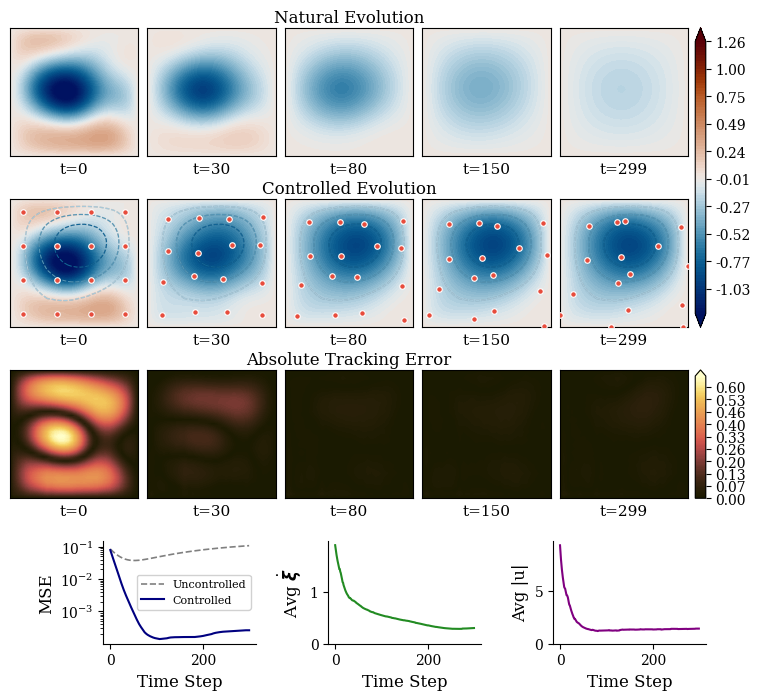

In [47]:
M_AGENTS = 16
print(f"--- Visualizing {M_AGENTS} Agents on Shared Shape ---")

# Initialize and load
model_16 = Heat2DControlNet(features=(16, 32))
params_16 = load_params_for_agents(model_16, PARAMS_FILE, M_AGENTS)

# Use shared conditions, but specific agent positions
xi_init_16 = get_agent_positions(M_AGENTS)

print("Running trajectories...")
z_traj_ctrl, xi_traj_ctrl, u_traj_ctrl, v_traj_ctrl = solve_with_policy(
    shared_z_init, xi_init_16, shared_z_target, params_16, model_16.apply, VIZ_T_STEPS
)
z_traj_unctrl, xi_traj_unctrl, _, _ = rollout_uncontrolled(
    shared_z_init, xi_init_16, VIZ_T_STEPS
)

# Compute Metrics
mse_ctrl = jnp.mean((z_traj_ctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
mse_unctrl = jnp.mean((z_traj_unctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
avg_speed = jnp.mean(jnp.sqrt(jnp.sum(v_traj_ctrl**2, axis=-1)), axis=1)
control_intensity = jnp.mean(jnp.abs(u_traj_ctrl), axis=1)

print(f"Final Tracking MSE (M=16): {float(mse_ctrl[-1]):.6f}")

create_paper_figure(z_traj_ctrl, z_traj_unctrl, xi_traj_ctrl, shared_z_target,
                    mse_ctrl, mse_unctrl, avg_speed, control_intensity)

--- Visualizing 25 Agents on Shared Shape ---
Running trajectories...
Final Tracking MSE (M=25): 0.000083


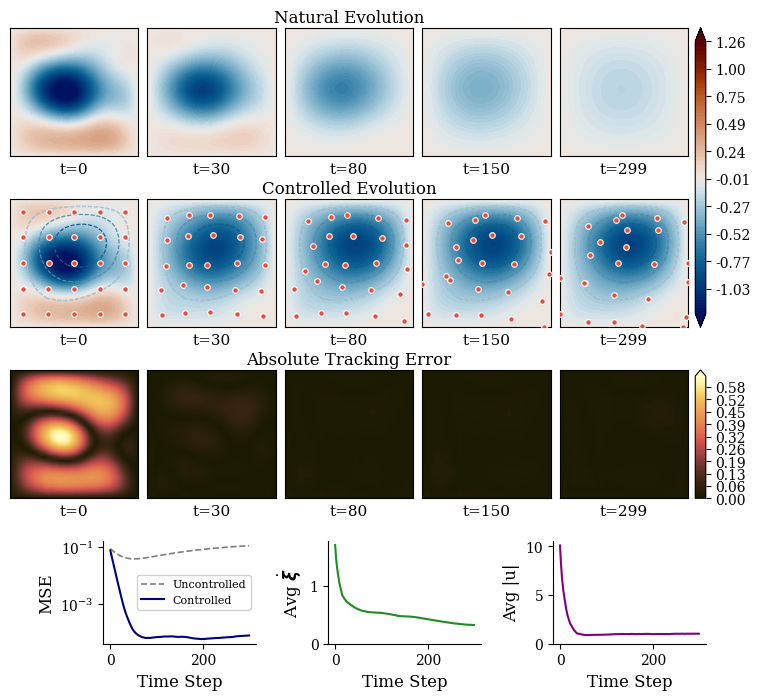

In [49]:
M_AGENTS = 25
print(f"--- Visualizing {M_AGENTS} Agents on Shared Shape ---")

# Initialize and load
model_25 = Heat2DControlNet(features=(16, 32))
params_25 = load_params_for_agents(model_25, PARAMS_FILE, M_AGENTS)

# Use shared conditions, but specific agent positions
xi_init_25 = get_agent_positions(M_AGENTS)

print("Running trajectories...")
z_traj_ctrl, xi_traj_ctrl, u_traj_ctrl, v_traj_ctrl = solve_with_policy(
    shared_z_init, xi_init_25, shared_z_target, params_25, model_25.apply, VIZ_T_STEPS
)
z_traj_unctrl, xi_traj_unctrl, _, _ = rollout_uncontrolled(
    shared_z_init, xi_init_25, VIZ_T_STEPS
)

# Compute Metrics
mse_ctrl = jnp.mean((z_traj_ctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
mse_unctrl = jnp.mean((z_traj_unctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
avg_speed = jnp.mean(jnp.sqrt(jnp.sum(v_traj_ctrl**2, axis=-1)), axis=1)
control_intensity = jnp.mean(jnp.abs(u_traj_ctrl), axis=1)

print(f"Final Tracking MSE (M=25): {float(mse_ctrl[-1]):.6f}")

create_paper_figure(z_traj_ctrl, z_traj_unctrl, xi_traj_ctrl, shared_z_target,
                    mse_ctrl, mse_unctrl, avg_speed, control_intensity)

--- Visualizing 36 Agents on Shared Shape ---
Running trajectories...
Final Tracking MSE (M=36): 0.000060


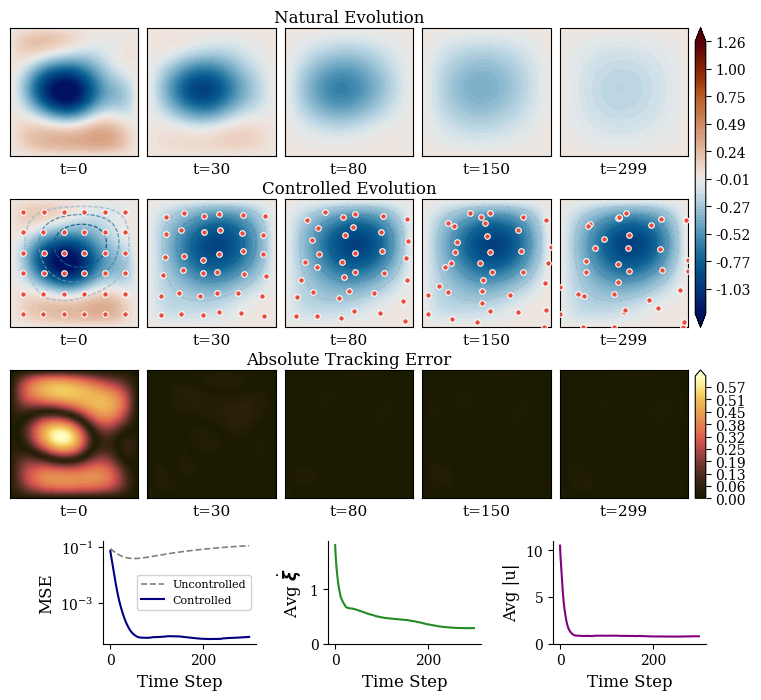

In [50]:
M_AGENTS = 36
print(f"--- Visualizing {M_AGENTS} Agents on Shared Shape ---")

# Initialize and load
model_36 = Heat2DControlNet(features=(16, 32))
params_36 = load_params_for_agents(model_36, PARAMS_FILE, M_AGENTS)

# Use shared conditions, but specific agent positions
xi_init_36 = get_agent_positions(M_AGENTS)

print("Running trajectories...")
z_traj_ctrl, xi_traj_ctrl, u_traj_ctrl, v_traj_ctrl = solve_with_policy(
    shared_z_init, xi_init_36, shared_z_target, params_36, model_36.apply, VIZ_T_STEPS
)
z_traj_unctrl, xi_traj_unctrl, _, _ = rollout_uncontrolled(
    shared_z_init, xi_init_36, VIZ_T_STEPS
)

# Compute Metrics
mse_ctrl = jnp.mean((z_traj_ctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
mse_unctrl = jnp.mean((z_traj_unctrl - shared_z_target[None, :, :])**2, axis=(1, 2))
avg_speed = jnp.mean(jnp.sqrt(jnp.sum(v_traj_ctrl**2, axis=-1)), axis=1)
control_intensity = jnp.mean(jnp.abs(u_traj_ctrl), axis=1)

print(f"Final Tracking MSE (M=36): {float(mse_ctrl[-1]):.6f}")

create_paper_figure(z_traj_ctrl, z_traj_unctrl, xi_traj_ctrl, shared_z_target,
                    mse_ctrl, mse_unctrl, avg_speed, control_intensity)